# NSF FMRG Data Challenge — Standalone Google Colab Notebook

This notebook is **fully standalone**. It does not import from `src/` or any local utility `.py` file.

It:
- reads thermal, SEM, and Bruker/Wyko ASC height-map data,
- extracts thermal segment,
- saves extracted thermal frames and thermal videos,
- creates visualizations,
- applies selected **display-only** tilt corrections for Tracks 10, 14, and 21, and
- saves all outputs into a new date-stamped folder.

Outputs are saved to:

```text
processed_data/run_outputs/<YYYYMMDD_HHMMSS>/
```


In [1]:
!pip install imageio-ffmpeg

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---- ----------------------------------- 3.1/31.2 MB 31.0 MB/s eta 0:00:01
   ------------ --------------------------- 10.0/31.2 MB 32.7 MB/s eta 0:00:01
   ---------------------- ----------------- 17.3/31.2 MB 33.1 MB/s eta 0:00:01
   ------------------------------ --------- 23.6/31.2 MB 33.1 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 33.3 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 31.6 MB/s  0:00:01


In [2]:
import matplotlib as mpl
import imageio_ffmpeg

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
mpl.rcParams["animation.ffmpeg_path"] = ffmpeg_exe

print("Using FFmpeg:", ffmpeg_exe)

Using FFmpeg: C:\Users\adity\AppData\Roaming\Python\Python313\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [3]:
from matplotlib import animation

print(
    "FFmpeg available:",
    animation.writers.is_available("ffmpeg")
)

FFmpeg available: True


In [6]:
# Google Colab setup (Uncomment if working on Google Drive)
# try:
#     from google.colab import drive
#     drive.mount('/content/drive', force_remount=False)
# except Exception as e:
#     print('Drive mount skipped:', repr(e))

from pathlib import Path
from datetime import datetime
import re
import json
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from PIL import Image, ImageOps
from scipy.io import loadmat
from scipy import ndimage

# For Google Drive
# MANUAL_PROJECT_DIR = '/content/drive/MyDrive/.../nsf-fmrg-data-challenge'
# For Local
MANUAL_PROJECT_DIR = 'C:/Users/adity/Documents/Coursework/Projects/nsf-fmrg-data-challenge'#'D:/Abhi Hanchate/NSF FMRG Data Challenge/'

PROJECT_DIR = Path(MANUAL_PROJECT_DIR)
print('PROJECT_DIR =', PROJECT_DIR)

TRACK_IDS = [8, 10, 14, 21]

COMMON_X_START_MM = 20.0
COMMON_X_END_MM = 100.0
COMMON_LENGTH_MM = COMMON_X_END_MM - COMMON_X_START_MM

THERMAL_FPS = 50.0
SCAN_SPEED_MM_PER_S = 10.0
THERMAL_MM_PER_FRAME = SCAN_SPEED_MM_PER_S / THERMAL_FPS
EXTRACTED_THERMAL_FRAMES = int(round(COMMON_LENGTH_MM / THERMAL_MM_PER_FRAME))

THERMAL_CMAP = 'jet'
THERMAL_VMIN = 1000.0
THERMAL_VMAX = 2500.0
THERMAL_PIXEL_SIZE_MM = 0.014  # 14 µm / pixel

HEIGHT_CMAP = 'jet'
HEIGHTMAP_RANGES_UM = {
    8:  (-50, 125),
    10: (-45, 110),
    14: (-45, 70),
    21: (-30, 45),
}

SELECTED_SLOPE_EFF = {
    10: 0.003562,
    14: -0.002517,
    21: -0.002448,
}
SELECTED_STRENGTH = {
    10: 1.00,
    14: 0.75,
    21: 1.00,
}

SEM_TILE_WIDTH_MM = 6.41

RAW_DIR = PROJECT_DIR / 'data' / 'raw'
THERMAL_DIR = RAW_DIR / 'thermal'
SEM_DIR = RAW_DIR / 'sem'
HEIGHT_DIR = RAW_DIR / 'height_maps'

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = PROJECT_DIR / 'processed_data' / 'run_outputs' / RUN_TAG

FIGURES_DIR = RUN_DIR / 'figures'
VIDEOS_DIR = RUN_DIR / 'videos'
THERMAL_SAVE_DIR = RUN_DIR / 'thermal_frames'
METADATA_DIR = RUN_DIR / 'metadata'
PAPER_FIG_DIR = RUN_DIR / 'paper_figures'

for p in [RUN_DIR, FIGURES_DIR, VIDEOS_DIR, THERMAL_SAVE_DIR, METADATA_DIR, PAPER_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('RUN_DIR =', RUN_DIR)
print('Expected extracted thermal frames:', EXTRACTED_THERMAL_FRAMES)


PROJECT_DIR = C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge
RUN_DIR = C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929
Expected extracted thermal frames: 400


In [7]:
# ============================================================
# Standalone helper functions
# ============================================================

def natural_key(s):
    s = str(s)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]


def find_track_file(root, track_id, suffixes):
    root = Path(root)
    suffixes = {s.lower() for s in suffixes}
    matches = []
    if not root.exists():
        return None
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in suffixes:
            name = p.name.lower()
            if re.search(rf'(^|[_\-\s]){track_id}($|[_\-\s\.])', name) or f'{track_id}' in name:
                matches.append(p)
    matches = sorted(matches, key=natural_key)
    return matches[0] if matches else None


def _loadmat_any(path):
    path = Path(path)
    try:
        data = loadmat(path)
        return {k: v for k, v in data.items() if not k.startswith('__')}
    except NotImplementedError:
        import h5py
        out = {}
        with h5py.File(path, 'r') as f:
            def visit(name, obj):
                if hasattr(obj, 'shape'):
                    try:
                        out[name] = np.array(obj)
                    except Exception:
                        pass
            f.visititems(visit)
        return out


def find_thermal_array(mat_dict):
    candidates = []
    for k, v in mat_dict.items():
        arr = np.asarray(v)
        arr = np.squeeze(arr)
        if arr.ndim not in (3, 4):
            continue
        if not np.issubdtype(arr.dtype, np.number):
            continue

        if arr.ndim == 4:
            small_dims = [i for i, d in enumerate(arr.shape) if d in (1, 3, 4)]
            if small_dims:
                arr = np.take(arr, indices=0, axis=small_dims[-1])
                arr = np.squeeze(arr)

        if arr.ndim != 3:
            continue

        score = arr.size * (10 if 400 in arr.shape else 1)
        candidates.append((score, k, arr))

    if not candidates:
        raise ValueError('No thermal-like array found in MAT file.')

    candidates.sort(key=lambda x: x[0], reverse=True)
    key, arr = candidates[0][1], candidates[0][2]
    shape = arr.shape

    if shape[0] == shape[1] and shape[2] != shape[0]:
        arr_t = np.moveaxis(arr, 2, 0)
    elif shape[1] == shape[2]:
        arr_t = arr
    else:
        arr_t = np.moveaxis(arr, int(np.argmax(shape)), 0)

    return np.asarray(arr_t, dtype=np.float32), key


def thermal_frame_score(frames, top_percentile=99.5):
    return np.array([np.nanpercentile(fr, top_percentile) for fr in frames], dtype=np.float64)


def largest_true_run(mask):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return None, None
    idx = np.flatnonzero(mask)
    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[breaks + 1]]
    stops = np.r_[idx[breaks] + 1, idx[-1] + 1]
    j = int(np.argmax(stops - starts))
    return int(starts[j]), int(stops[j])


def detect_laser_on_interval(frames):
    score = thermal_frame_score(frames)
    n = len(score)
    pre = score[:max(5, n // 10)]

    med = np.nanmedian(pre)
    mad = 1.4826 * np.nanmedian(np.abs(pre - med))

    range_thr = np.nanmin(score) + 0.20 * (np.nanmax(score) - np.nanmin(score))
    mad_thr = med + 8.0 * max(mad, 1e-12)
    threshold = max(range_thr, mad_thr)

    mask = score > threshold
    on_start, on_stop = largest_true_run(mask)

    if on_start is None:
        raise ValueError("Could not detect laser-on interval. Inspect thermal score manually.")

    return on_start, on_stop, score, threshold


def extract_final_thermal_frames(track_id):
    path = find_track_file(THERMAL_DIR, track_id, ['.mat'])
    if path is None:
        raise FileNotFoundError(f"No MAT file found for track {track_id} in {THERMAL_DIR}")

    mat = _loadmat_any(path)
    frames, key = find_thermal_array(mat)

    on_start, on_stop, score, threshold = detect_laser_on_interval(frames)

    stop_idx = int(on_stop)
    start_idx = max(0, stop_idx - EXTRACTED_THERMAL_FRAMES)

    segment = frames[start_idx:stop_idx]
    indices = np.arange(start_idx, stop_idx)
    x_mm_center = COMMON_X_END_MM - ((stop_idx - indices) - 0.5) * THERMAL_MM_PER_FRAME

    return {
        'file': str(path),
        'variable': key,
        'raw_frames': frames,
        'frames': segment,
        'x_mm_center': x_mm_center,
        'on_start': int(on_start),
        'on_stop': int(on_stop),
        'start_idx': int(start_idx),
        'stop_idx': int(stop_idx),
        'score': score,
        'threshold': float(threshold),
    }


def get_sem_tile_paths(track_id):
    root = SEM_DIR / f'SEM_{track_id}' / 'PlainImages'
    if not root.exists():
        return []
    suffixes = {'.tif', '.tiff', '.png', '.jpg', '.jpeg'}
    files = [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in suffixes]
    return sorted(files, key=natural_key)


def load_sem_tile(path):
    return np.asarray(ImageOps.grayscale(Image.open(path)))


def parse_wyko_header(path):
    header = {}
    with open(path, 'r', errors='replace') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[0].lower() == 'x' and parts[1].lower() == 'size':
                header['x_size'] = int(float(parts[2]))
            elif len(parts) >= 3 and parts[0].lower() == 'y' and parts[1].lower() == 'size':
                header['y_size'] = int(float(parts[2]))
            elif parts and parts[0].lower() == 'pixel_size':
                header['pixel_size_mm'] = float(parts[-1])

            if parts and parts[0].upper() == 'RAW_DATA':
                break
    return header


def load_wyko_asc(track_id, crop_to_common=True):
    path = find_track_file(HEIGHT_DIR, track_id, ['.asc', '.txt'])
    if path is None:
        raise FileNotFoundError(f"No ASC/TXT file found for track {track_id} in {HEIGHT_DIR}")

    header = parse_wyko_header(path)

    x_size = int(header['x_size'])
    y_size = int(header['y_size'])
    pixel = float(header.get('pixel_size_mm', 0.003982))
    n_expected = x_size * y_size

    z_mm_flat = np.empty(n_expected, dtype=np.float32)
    z_mm_flat.fill(np.nan)

    count = 0
    in_raw = False
    first_row = None
    last_row = None

    with open(path, 'r', errors='replace') as f:
        for line in f:
            parts = line.strip().split()

            if not in_raw:
                if parts and parts[0].upper() == 'RAW_DATA':
                    in_raw = True
                continue

            if len(parts) < 3:
                continue

            x_val = float(parts[0])
            y_val = float(parts[1])
            z_tok = parts[2]

            if first_row is None:
                first_row = (x_val, y_val, z_tok)
            last_row = (x_val, y_val, z_tok)

            z_mm_flat[count] = np.nan if z_tok.lower() == 'bad' else float(z_tok) * 1e-6
            count += 1

            if count >= n_expected:
                break

    if count < n_expected:
        warnings.warn(f"Read {count} rows but expected {n_expected}. Results may be truncated.")

    Z_x_y = z_mm_flat.reshape((x_size, y_size))
    Z_yx = Z_x_y.T

    x_local = np.arange(x_size, dtype=np.float64) * pixel
    y_mm = np.arange(y_size, dtype=np.float64) * pixel

    # Corrected ASC direction:
    # raw local x = 0 corresponds to actual 100 mm side.
    x_actual_raw = 100.0 - x_local

    sort_idx = np.argsort(x_actual_raw)
    x_actual = x_actual_raw[sort_idx]
    x_local_sorted = x_local[sort_idx]
    Z_yx = Z_yx[:, sort_idx]

    if crop_to_common:
        mask = (x_actual >= COMMON_X_START_MM) & (x_actual <= COMMON_X_END_MM)
        x_actual = x_actual[mask]
        x_local_sorted = x_local_sorted[mask]
        Z_yx = Z_yx[:, mask]

    return {
        'file': str(path),
        'header': header,
        'first_row': first_row,
        'last_row': last_row,
        'Z_mm': Z_yx,
        'x_actual_mm': x_actual,
        'x_local_mm': x_local_sorted,
        'y_mm': y_mm,
    }


def robust_plane_detrend(Z_mm, x_mm, y_mm, stride_x=40, stride_y=2):
    Zs = Z_mm[::stride_y, ::stride_x]
    xs = x_mm[::stride_x]
    ys = y_mm[::stride_y]

    Xs, Ys = np.meshgrid(xs, ys)
    z = Zs.ravel()
    A = np.c_[Xs.ravel(), Ys.ravel(), np.ones(Xs.size)]

    valid = np.isfinite(z)
    if valid.sum() < 100:
        return Z_mm.copy(), None

    keep = valid.copy()
    coef = None

    for _ in range(3):
        coef, *_ = np.linalg.lstsq(A[keep], z[keep], rcond=None)
        resid = z - A @ coef
        rv = resid[valid]
        lo, hi = np.nanpercentile(rv, [5, 95])
        keep_new = valid & (resid >= lo) & (resid <= hi)

        if keep_new.sum() < 100:
            break

        keep = keep_new

    plane = coef[0] * x_mm[None, :] + coef[1] * y_mm[:, None] + coef[2]
    return Z_mm - plane, coef


def display_shear_grid(x_mm, y_mm, slope_eff, strength=1.0, reference_x=None):
    """
    Display-only shear correction.

    This does NOT resample the height values. It only changes the plotted y-coordinate grid.
    """
    x_mm = np.asarray(x_mm)
    y_mm = np.asarray(y_mm)

    if reference_x is None:
        reference_x = 0.5 * (float(x_mm[0]) + float(x_mm[-1]))

    correction = strength * slope_eff * (x_mm - reference_x)
    Y_plot = y_mm[:, None] - correction[None, :]
    X_plot = np.tile(x_mm[None, :], (len(y_mm), 1))

    return X_plot, Y_plot, correction


def plot_height_pcolormesh(X_plot, Y_plot, Z_um, track_id, title, out_stem=None):
    vmin_um, vmax_um = HEIGHTMAP_RANGES_UM[track_id]

    fig, ax = plt.subplots(figsize=(10.8, 2.9))
    im = ax.pcolormesh(
        X_plot, Y_plot, Z_um,
        cmap=HEIGHT_CMAP,
        vmin=vmin_um,
        vmax=vmax_um,
        shading='auto',
    )

    ax.set_ylim(float(np.nanmax(Y_plot)), float(np.nanmin(Y_plot)))
    ax.set_xlim(float(np.nanmin(X_plot)), float(np.nanmax(X_plot)))
    ax.set_xlabel('actual x (mm)')
    ax.set_ylabel('cross-track y (mm)')
    ax.set_title(title, fontsize=12)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
    cb.set_label('height (µm)')

    plt.tight_layout()

    if out_stem is not None:
        png = FIGURES_DIR / f'{out_stem}.png'
        pdf = FIGURES_DIR / f'{out_stem}.pdf'
        fig.savefig(png, dpi=400, bbox_inches='tight')
        fig.savefig(pdf, bbox_inches='tight')
        print('Saved:', png)
        print('Saved:', pdf)

    plt.show()
    return fig


## 1. Extract final thermal frames and save thermal videos


In [8]:
thermal_summary = {}
thermal_results = {}

for track_id in TRACK_IDS:
    print('\n' + '=' * 90)
    print(f'THERMAL TRACK {track_id}')

    result = extract_final_thermal_frames(track_id)
    thermal_results[track_id] = result

    out_dir = THERMAL_SAVE_DIR / f'Track_{track_id}'
    out_dir.mkdir(parents=True, exist_ok=True)

    np.save(out_dir / f'Track_{track_id}_thermal_frames.npy', result['frames'])
    np.save(out_dir / f'Track_{track_id}_x_mm_center.npy', result['x_mm_center'])

    meta = {
        'track_id': track_id,
        'file': result['file'],
        'variable': result['variable'],
        'raw_shape': list(map(int, result['raw_frames'].shape)),
        'laser_on': [result['on_start'], result['on_stop']],
        'extracted_indices': [result['start_idx'], result['stop_idx']],
        'extracted_frames': int(result['frames'].shape[0]),
        'x_first_last_mm': [float(result['x_mm_center'][0]), float(result['x_mm_center'][-1])],
    }

    with open(out_dir / f'Track_{track_id}_thermal_metadata.json', 'w') as f:
        json.dump(meta, f, indent=2)

    thermal_summary[str(track_id)] = meta

    # Thermal video with high bitrate, no downsampling.
    video_path = VIDEOS_DIR / f'Track_{track_id}_thermal_20to100mm.mp4'
    frames = result['frames']
    x_mm = result['x_mm_center']
    extent = [0, frames.shape[2] * THERMAL_PIXEL_SIZE_MM, frames.shape[1] * THERMAL_PIXEL_SIZE_MM, 0]

    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    im = ax.imshow(frames[0], cmap=THERMAL_CMAP, vmin=THERMAL_VMIN, vmax=THERMAL_VMAX, extent=extent)
    title = ax.set_title(f'Track {track_id} | x ≈ {x_mm[0]:.1f} mm', fontsize=12)
    ax.set_xlabel('thermal local x (mm)')
    ax.set_ylabel('thermal local y (mm)')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('temperature / intensity')

    def update(i):
        im.set_data(frames[i])
        title.set_text(f'Track {track_id} | x ≈ {x_mm[i]:.1f} mm')
        return [im, title]

    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=80, blit=False)

    try:
        writer = animation.FFMpegWriter(fps=10, bitrate=8000)
        ani.save(str(video_path), writer=writer)
        saved_video = video_path
    except Exception as e:
        print('MP4 export failed; saving GIF instead. Reason:', repr(e))
        gif_path = video_path.with_suffix('.gif')
        ani.save(str(gif_path), writer=animation.PillowWriter(fps=10))
        saved_video = gif_path

    plt.close(fig)
    print('Saved thermal frames to:', out_dir)
    print('Saved video to:', saved_video)

with open(METADATA_DIR / 'thermal_summary.json', 'w') as f:
    json.dump(thermal_summary, f, indent=2)

print('\nSaved thermal metadata:', METADATA_DIR / 'thermal_summary.json')



THERMAL TRACK 8
Saved thermal frames to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\thermal_frames\Track_8
Saved video to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\videos\Track_8_thermal_20to100mm.mp4

THERMAL TRACK 10
Saved thermal frames to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\thermal_frames\Track_10
Saved video to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\videos\Track_10_thermal_20to100mm.mp4

THERMAL TRACK 14
Saved thermal frames to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\thermal_frames\Track_14
Saved video to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\videos

## 2. Thermal laser-stop detection figures


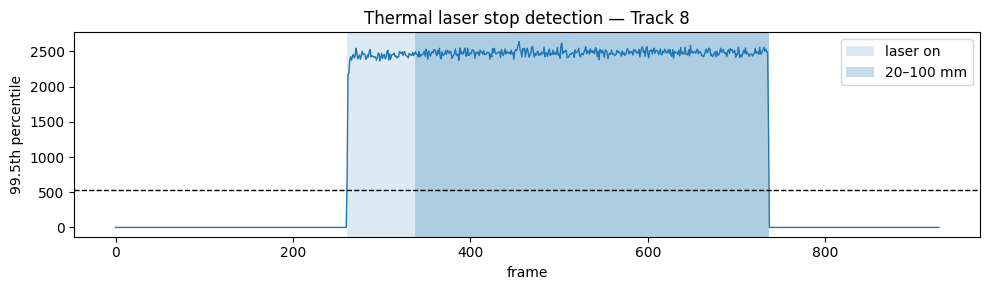

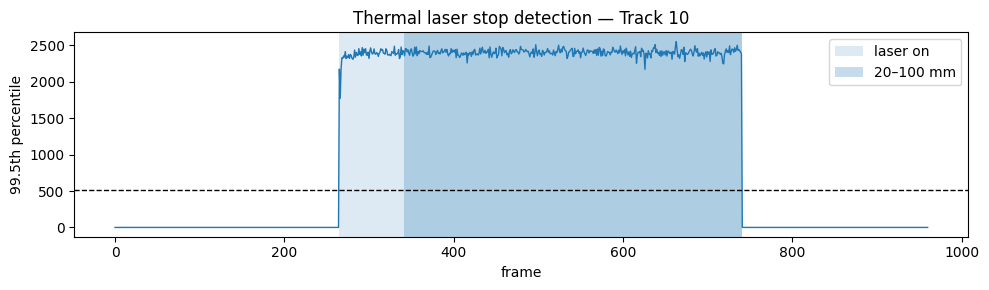

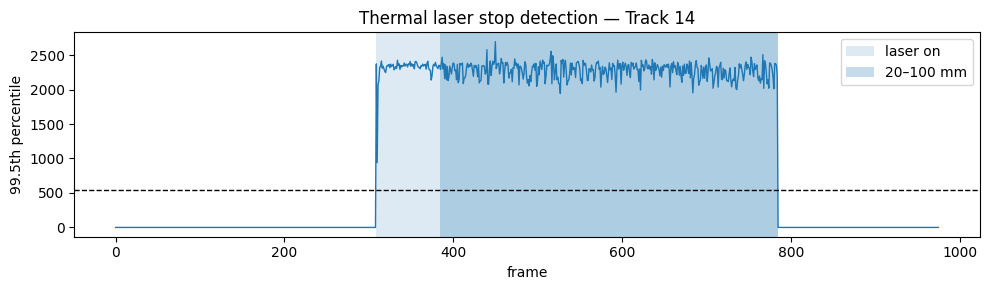

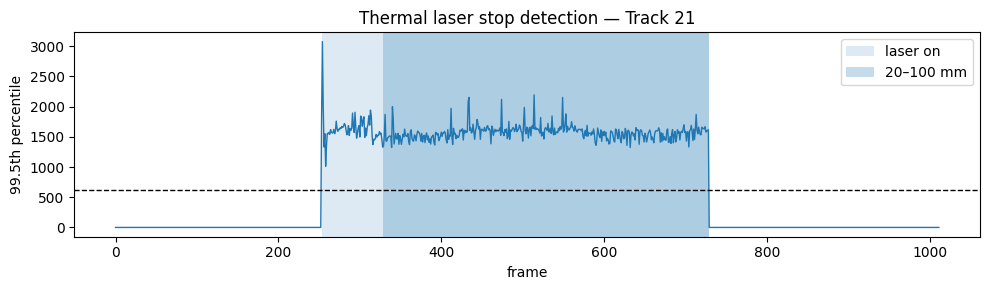

In [9]:
for track_id, result in thermal_results.items():
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(result['score'], lw=1.0)
    ax.axhline(result['threshold'], ls='--', color='k', lw=1)
    ax.axvspan(result['on_start'], result['on_stop'], alpha=0.15, label='laser on')
    ax.axvspan(result['start_idx'], result['stop_idx'], alpha=0.25, label='20–100 mm')
    ax.set_title(f'Thermal laser stop detection — Track {track_id}', fontsize=12)
    ax.set_xlabel('frame')
    ax.set_ylabel('99.5th percentile')
    ax.legend(loc='upper right')
    plt.tight_layout()

    fig.savefig(FIGURES_DIR / f'thermal_detection_track_{track_id}.png', dpi=400, bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'thermal_detection_track_{track_id}.pdf', bbox_inches='tight')
    plt.show()


## 3. SEM tile visualization without stitching



SEM TRACK 8: 13 tiles


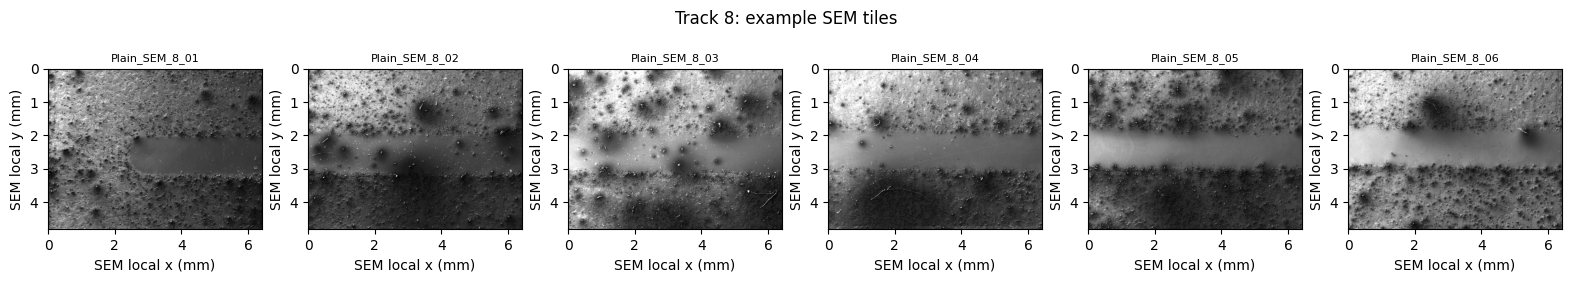


SEM TRACK 10: 13 tiles


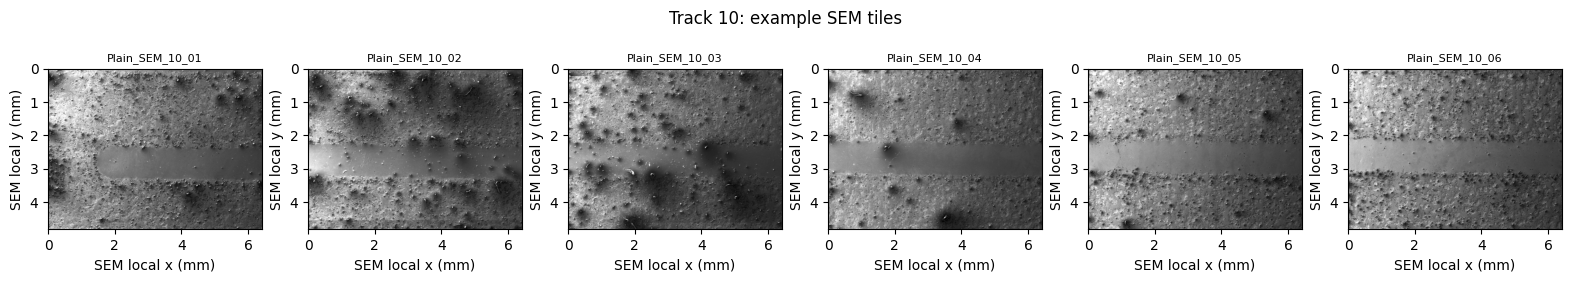


SEM TRACK 14: 13 tiles


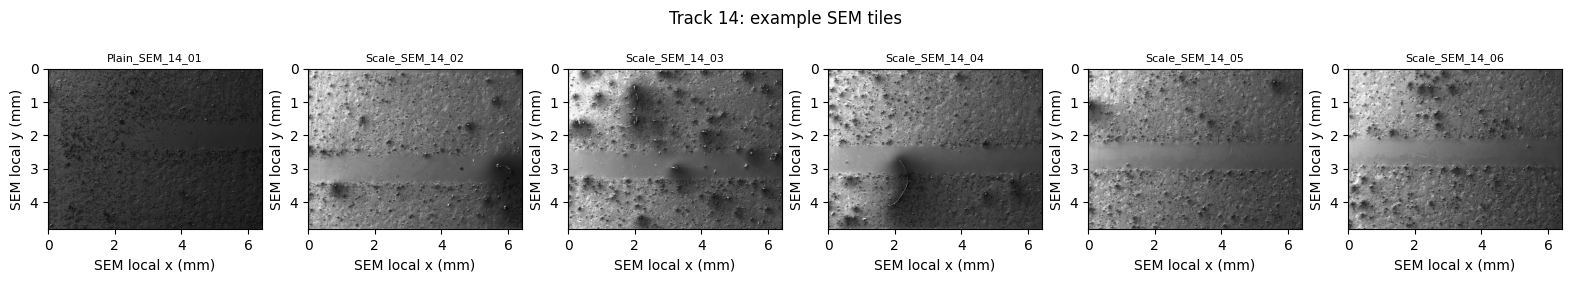


SEM TRACK 21: 14 tiles


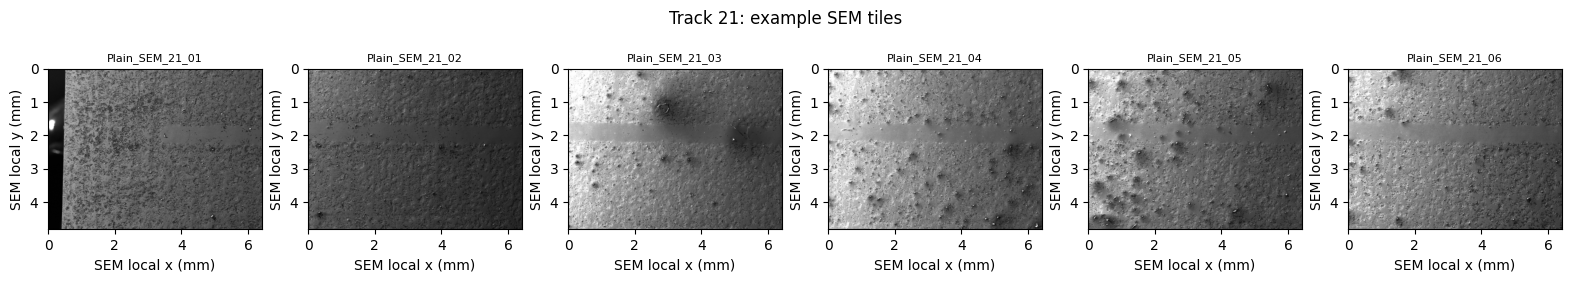

In [10]:
sem_summary = {}

for track_id in TRACK_IDS:
    tile_paths = get_sem_tile_paths(track_id)
    sem_summary[str(track_id)] = {
        'tile_count': len(tile_paths),
        'files': [p.name for p in tile_paths],
    }

    print('\n' + '=' * 90)
    print(f'SEM TRACK {track_id}: {len(tile_paths)} tiles')

    if not tile_paths:
        continue

    n_show = min(6, len(tile_paths))
    fig, axes = plt.subplots(1, n_show, figsize=(2.6 * n_show, 2.7), constrained_layout=True)

    for ax, p in zip(np.atleast_1d(axes), tile_paths[:n_show]):
        img = load_sem_tile(p)
        h, w = img.shape
        sem_height_mm = SEM_TILE_WIDTH_MM * h / w
        extent = [0, SEM_TILE_WIDTH_MM, sem_height_mm, 0]

        im = ax.imshow(img, cmap='gray', extent=extent)
        ax.set_title(p.stem, fontsize=8)
        ax.set_xlabel('SEM local x (mm)')
        ax.set_ylabel('SEM local y (mm)')

    fig.suptitle(f'Track {track_id}: example SEM tiles', fontsize=12)
    fig.savefig(FIGURES_DIR / f'sem_tiles_track_{track_id}.png', dpi=400, bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'sem_tiles_track_{track_id}.pdf', bbox_inches='tight')
    plt.show()

with open(METADATA_DIR / 'sem_summary.json', 'w') as f:
    json.dump(sem_summary, f, indent=2)


## 4. Height-map loading and selected display-only tilt correction



HEIGHT MAP TRACK 8
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_8.png
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_8.pdf


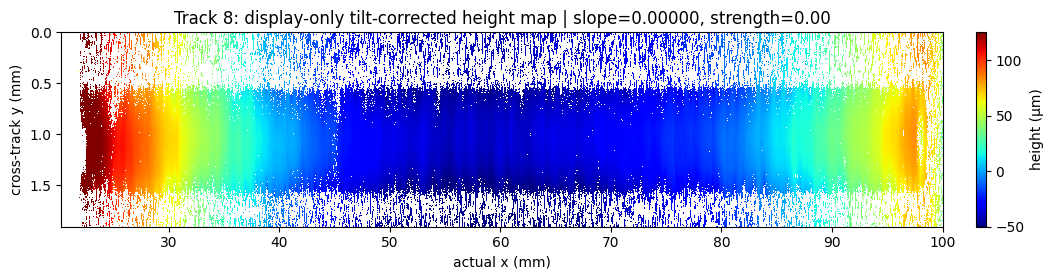


HEIGHT MAP TRACK 10
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_10.png
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_10.pdf


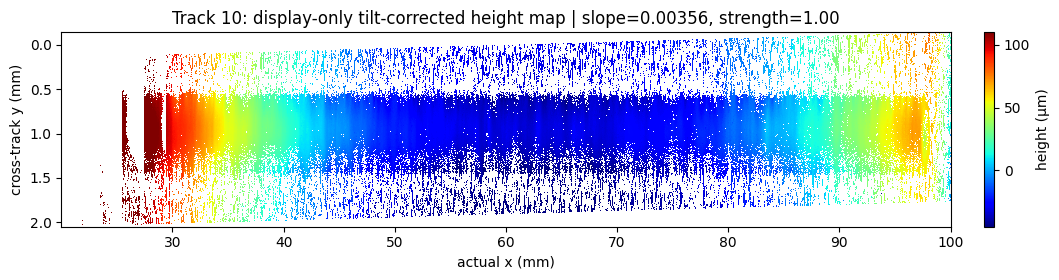


HEIGHT MAP TRACK 14
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_14.png
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_14.pdf


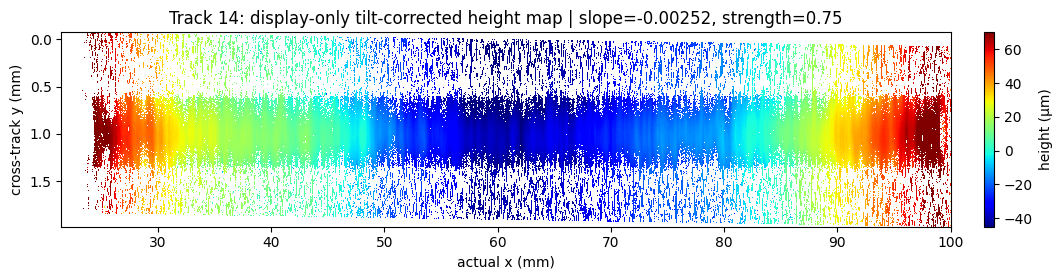


HEIGHT MAP TRACK 21
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_21.png
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\figures\heightmap_tilt_corrected_track_21.pdf


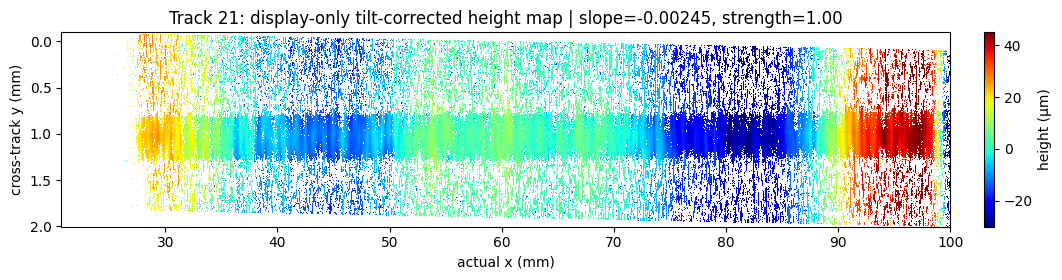


Saved height metadata: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\metadata\height_summary.json


In [11]:
height_summary = {}
height_results = {}

for track_id in TRACK_IDS:
    print('\n' + '=' * 90)
    print(f'HEIGHT MAP TRACK {track_id}')

    data = load_wyko_asc(track_id, crop_to_common=True)
    Z_detrended, coef = robust_plane_detrend(data['Z_mm'], data['x_actual_mm'], data['y_mm'])

    x = data['x_actual_mm']
    y = data['y_mm']

    slope_eff = SELECTED_SLOPE_EFF.get(track_id, 0.0)
    strength = SELECTED_STRENGTH.get(track_id, 0.0)

    X_plot, Y_plot, correction = display_shear_grid(
        x, y, slope_eff=slope_eff, strength=strength
    )

    height_results[track_id] = {
        'data': data,
        'Z_detrended': Z_detrended,
        'X_plot': X_plot,
        'Y_plot': Y_plot,
        'slope_eff': slope_eff,
        'strength': strength,
        'plane_coef': None if coef is None else [float(c) for c in coef],
    }

    height_summary[str(track_id)] = {
        'file': data['file'],
        'header': data['header'],
        'shape': list(map(int, Z_detrended.shape)),
        'x_actual_first_last_mm': [float(x[0]), float(x[-1])],
        'y_first_last_mm': [float(y[0]), float(y[-1])],
        'selected_slope_eff_mm_per_mm': float(slope_eff),
        'selected_strength': float(strength),
        'max_display_correction_mm': float(np.nanmax(np.abs(correction))),
    }

    title = (
        f'Track {track_id}: display-only tilt-corrected height map | '
        f'slope={slope_eff:.5f}, strength={strength:.2f}'
    )

    plot_height_pcolormesh(
        X_plot,
        Y_plot,
        Z_detrended * 1000.0,
        track_id,
        title,
        out_stem=f'heightmap_tilt_corrected_track_{track_id}',
    )

with open(METADATA_DIR / 'height_summary.json', 'w') as f:
    json.dump(height_summary, f, indent=2)

print('\nSaved height metadata:', METADATA_DIR / 'height_summary.json')


## 5. Three-panel figure


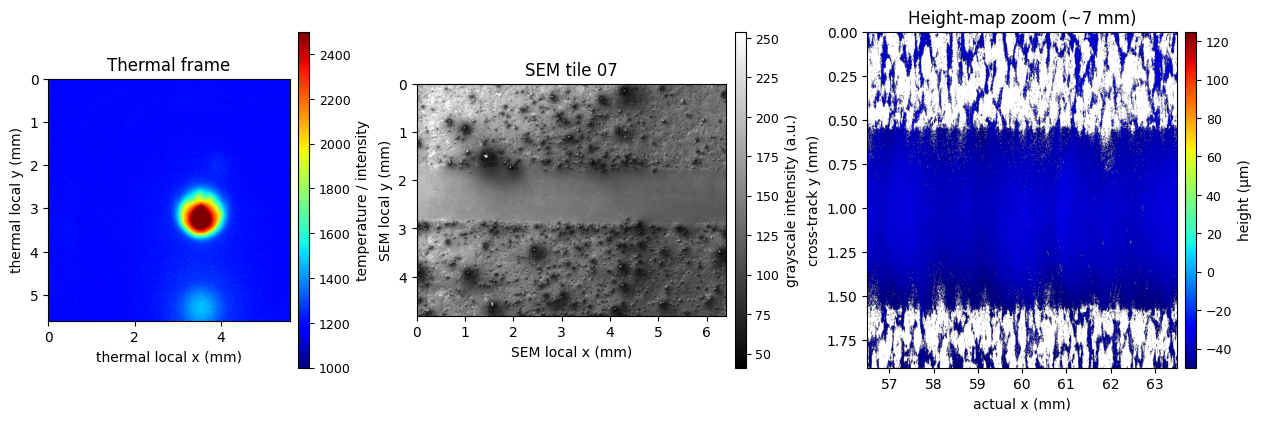

Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\paper_figures\modality_examples_three_panel.png
Saved: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\run_outputs\20260714_105929\paper_figures\modality_examples_three_panel.pdf
Also saved to: C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\paper\figures


In [12]:
EXAMPLE_TRACK = 8
THERMAL_TARGET_X_MM = 60.0
HEIGHT_TARGET_X_CENTER_MM = 60.0
HEIGHT_TARGET_WIDTH_MM = 7.0
SEM_TILE_INDEX = 7  # 7th tile if available

# Thermal panel
thermal = thermal_results[EXAMPLE_TRACK]
thermal_idx = int(np.argmin(np.abs(thermal['x_mm_center'] - THERMAL_TARGET_X_MM)))
thermal_img = thermal['frames'][thermal_idx]
thermal_extent = [
    0,
    thermal_img.shape[1] * THERMAL_PIXEL_SIZE_MM,
    thermal_img.shape[0] * THERMAL_PIXEL_SIZE_MM,
    0,
]

# SEM panel
sem_tiles = get_sem_tile_paths(EXAMPLE_TRACK)
sem_path = sem_tiles[min(SEM_TILE_INDEX, len(sem_tiles) - 1)]
sem_img = load_sem_tile(sem_path)
sem_h, sem_w = sem_img.shape
sem_height_mm = SEM_TILE_WIDTH_MM * sem_h / sem_w
sem_extent = [0, SEM_TILE_WIDTH_MM, sem_height_mm, 0]

# Height-map panel
height_bundle = height_results[EXAMPLE_TRACK]
height_data = height_bundle['data']
Z_hm = height_bundle['Z_detrended']
x = height_data['x_actual_mm']
y = height_data['y_mm']

mask = (
    (x >= HEIGHT_TARGET_X_CENTER_MM - HEIGHT_TARGET_WIDTH_MM / 2)
    & (x <= HEIGHT_TARGET_X_CENTER_MM + HEIGHT_TARGET_WIDTH_MM / 2)
)

Z_crop_um = Z_hm[:, mask] * 1000.0
vmin_um, vmax_um = HEIGHTMAP_RANGES_UM[EXAMPLE_TRACK]
height_extent = [float(x[mask][0]), float(x[mask][-1]), float(y[-1]), float(y[0])]

# Figure with labels, ticks, and colorbars
fig = plt.figure(figsize=(12.5, 4.1), constrained_layout=True)
gs = fig.add_gridspec(1, 6, width_ratios=[1.0, 0.045, 1.28, 0.045, 1.28, 0.045])

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(
    thermal_img,
    cmap=THERMAL_CMAP,
    vmin=THERMAL_VMIN,
    vmax=THERMAL_VMAX,
    extent=thermal_extent,
)
ax1.set_title('Thermal frame', fontsize=12)
ax1.set_xlabel('thermal local x (mm)')
ax1.set_ylabel('thermal local y (mm)')
cax1 = fig.add_subplot(gs[0, 1])
cb1 = fig.colorbar(im1, cax=cax1)
cb1.set_label('temperature / intensity')

ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(sem_img, cmap='gray', extent=sem_extent)
ax2.set_title('SEM tile 07', fontsize=12)
ax2.set_xlabel('SEM local x (mm)')
ax2.set_ylabel('SEM local y (mm)')
cax2 = fig.add_subplot(gs[0, 3])
cb2 = fig.colorbar(im2, cax=cax2)
cb2.set_label('grayscale intensity (a.u.)')

ax3 = fig.add_subplot(gs[0, 4])
im3 = ax3.imshow(
    Z_crop_um,
    cmap=HEIGHT_CMAP,
    aspect='auto',
    extent=height_extent,
    vmin=vmin_um,
    vmax=vmax_um,
)
ax3.set_title('Height-map zoom (~7 mm)', fontsize=12)
ax3.set_xlabel('actual x (mm)')
ax3.set_ylabel('cross-track y (mm)')
cax3 = fig.add_subplot(gs[0, 5])
cb3 = fig.colorbar(im3, cax=cax3)
cb3.set_label('height (µm)')

for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='both', labelsize=10)

for cb in [cb1, cb2, cb3]:
    cb.ax.tick_params(labelsize=9)

png_path = PAPER_FIG_DIR / 'modality_examples_three_panel.png'
pdf_path = PAPER_FIG_DIR / 'modality_examples_three_panel.pdf'

fig.savefig(png_path, dpi=400, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
plt.show()

print('Saved:', png_path)
print('Saved:', pdf_path)

# Optional: save directly into PROJECT_DIR/paper/figures if that exists.
paper_repo_fig_dir = PROJECT_DIR / 'paper' / 'figures'
if paper_repo_fig_dir.exists():
    fig.savefig(paper_repo_fig_dir / 'modality_examples_three_panel.png', dpi=400, bbox_inches='tight')
    fig.savefig(paper_repo_fig_dir / 'modality_examples_three_panel.pdf', bbox_inches='tight')
    print('Also saved to:', paper_repo_fig_dir)
